In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/UNet_metrics_train.csv"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# Direct UNet — Field Reconstruction from Sparse Observations (GP / SPDE)

Deterministic supervised mapping:

$$\hat{x} = \text{UNet}(y_\text{filled},\; m)$$

| Input | Shape | Description |
|---|---|---|
| $y_\text{filled}$ | `(B, C, H, W)` | Observations with NaN → 0 |
| $m$ | `(B, C, H, W)` | Binary mask (1 = observed, 0 = missing) |

The network is trained with MSE loss against the full ground truth $x$ at all pixels.


## 🛠️ Setup & Imports


In [4]:
!nvidia-smi


Mon Aug  3 08:59:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:82:00.0 Off |                    0 |
| N/A   48C    P0             66W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # → consistency/  (for consistency_models)
sys.path.append('../../..')  # → 4dvarnet-starter-devs/  (for src)

from consistency_models.consistency_models_CM import (
    ConsistencySamplingAndEditingFewSteps_TimeEmbedding,
    ConsistencyTrainingFewSteps_TimeEmbedding,
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("⚠️  properscoring not installed — CRPS disabled. Install with: pip install properscoring")

## 🧠 Implementation  ### DataModule — SPDE Diffusion Dataset


<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

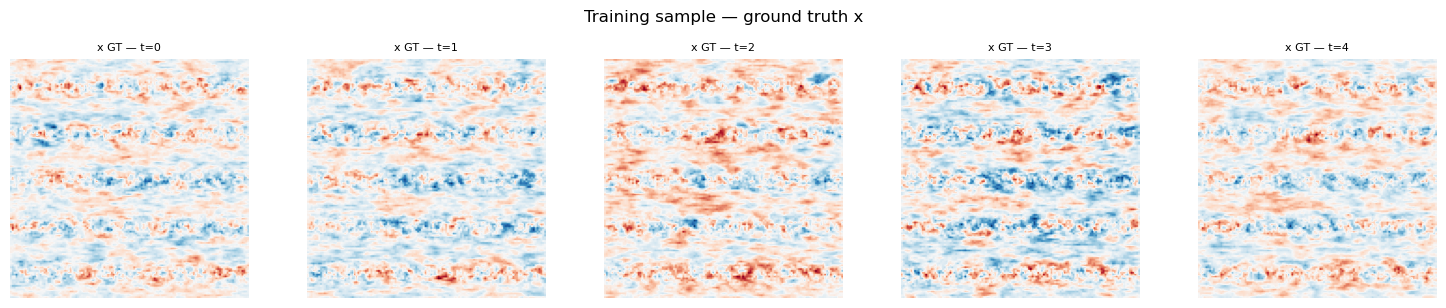

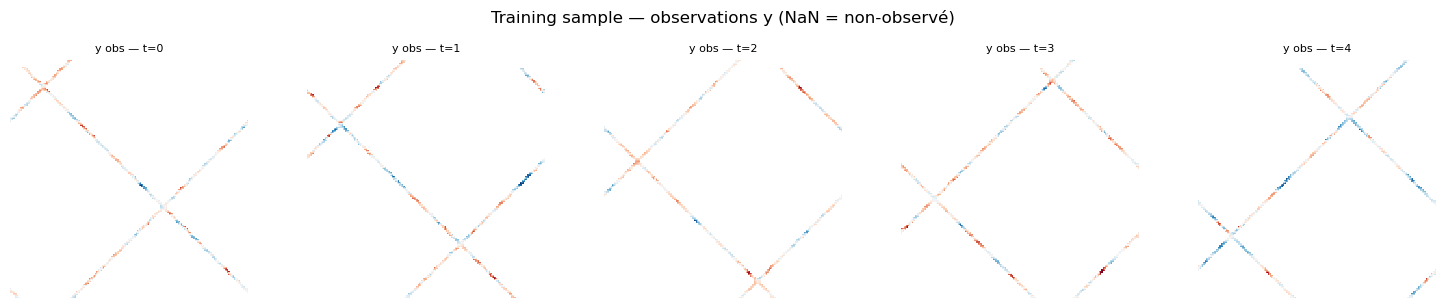

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

# NOTE: this cell previously only inspected the raw NetCDF file and never
# actually built `datamodule` -- leaving `C`/`datamodule` undefined and
# crashing the training cell below with NameError: name 'C' is not defined.
# Instantiation restored, matching the other GP notebooks (CM_spde, FM_spde, ...).
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes — input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — ground truth x", y=1.01)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs — t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample — observations y (NaN = non-observé)", y=1.01)
plt.tight_layout(); plt.show()

### UNet Building Blocks


In [8]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100×100 → 104×104, must be a multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)  # left, right, top, bottom
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### Direct UNet

The UNet takes as input the concatenation `(y_filled, mask_obs)` → `2×C` input channels.
A reflection padding to the nearest multiple of 8 is applied at input and removed at output.
There is no noise-level conditioning (a zero dummy embedding is used to preserve the UNetBlock interface).


In [9]:
@dataclass
class DirectUNetConfig:
    channels: int = 5                                        # = window_size
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class DirectUNet(nn.Module):
    """
    Direct UNet for field reconstruction from sparse observations.

    Input:  cat(y_filled, mask_obs)  →  2*C channels
    Output: x_hat                    →  C channels

    y_filled : (B, C, H, W)  observations with NaN → 0
    mask_obs : (B, C, H, W)  binary float (1=observed, 0=missing)
    """
    def __init__(self, config: DirectUNetConfig) -> None:
        super().__init__()
        self.config = config
        C = config.channels
        D = config.top_blocks_channels[0]
        COND = 1   # dummy conditioning dimension

        # Project (y_filled, mask) jointly: 2C → D
        self.input_projection = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        # Dummy noise-level embedding (always zeros) — keeps UNetBlock interface
        self.dummy_emb = nn.Linear(COND, COND)

        all_channels = config.top_blocks_channels + config.mid_blocks_channels
        n_blocks     = (config.top_blocks_n_blocks_per_resolution
                        + config.mid_blocks_n_blocks_per_resolution)
        has_res      = (config.top_blocks_has_resampling
                        + config.mid_blocks_has_resampling)
        dropouts     = (config.top_blocks_dropout + config.mid_blocks_dropout)

        enc_channels = [D] + list(all_channels)
        self.encoder_blocks = nn.ModuleList()
        self.downsamplers    = nn.ModuleList()
        for i in range(len(all_channels)):
            blocks = nn.ModuleList([
                UNetBlock(enc_channels[i] if j == 0 else all_channels[i],
                          all_channels[i], COND, dropouts[i])
                for j in range(n_blocks[i])
            ])
            self.encoder_blocks.append(blocks)
            self.downsamplers.append(Downsample(all_channels[i]) if has_res[i] else nn.Identity())

        self.attention = SelfAttention(all_channels[-1], all_channels[-1], config.n_heads)

        # Decoder. The forward pass upsamples the *incoming* feature map (the previous
        # stage's output) before concatenating the skip, so every module at stage i must
        # be sized by the incoming channel count `prev_channels[i]`, not `dec_channels[i]`.
        dec_channels  = list(reversed(all_channels))                 # [512, 256, 128, 64]
        prev_channels = [all_channels[-1]] + dec_channels[:-1]       # [512, 512, 256, 128]
        self.decoder_blocks = nn.ModuleList()
        self.upsamplers      = nn.ModuleList()
        for i in range(len(dec_channels)):
            skip_ch = dec_channels[i]
            in_ch   = prev_channels[i] + skip_ch
            blocks  = nn.ModuleList([
                UNetBlock(in_ch if j == 0 else dec_channels[i],
                          dec_channels[i], COND, dropouts[-(i+1)])
                for j in range(n_blocks[-(i+1)])
            ])
            self.decoder_blocks.append(blocks)
            self.upsamplers.append(
                Upsample(prev_channels[i]) if has_res[-(i+1)] else nn.Identity()
            )

        self.output_projection = nn.Sequential(
            GroupNorm(dec_channels[-1]),
            nn.SiLU(),
            nn.Conv2d(dec_channels[-1], C, kernel_size=3, padding="same"),
        )

    @staticmethod
    def _pad(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int,int,int,int]]:
        H, W = x.shape[-2], x.shape[-1]
        pad_h = (multiple - H % multiple) % multiple
        pad_w = (multiple - W % multiple) % multiple
        padding = (0, pad_w, 0, pad_h)
        return F.pad(x, padding, mode="reflect"), padding

    @staticmethod
    def _unpad(x: Tensor, padding: Tuple[int,int,int,int]) -> Tensor:
        _, pad_w, _, pad_h = padding
        if pad_h > 0: x = x[..., :-pad_h, :]
        if pad_w > 0: x = x[..., :-pad_w]
        return x

    def forward(self, y_filled: Tensor, mask_obs: Tensor) -> Tensor:
        x = torch.cat([y_filled, mask_obs], dim=1)   # (B, 2C, H, W)
        x, padding = self._pad(x)
        x = self.input_projection(x)                 # (B, D, H', W')

        # 4D dummy conditioning (B, COND, 1, 1) — time_level_projection is a Conv2d
        cond = torch.zeros(x.shape[0], 1, 1, 1, device=x.device, dtype=x.dtype)

        skips = []
        for blocks, down in zip(self.encoder_blocks, self.downsamplers):
            for blk in blocks:
                x = blk(x, cond)
            skips.append(x)
            x = down(x)

        x = self.attention(x)

        for blocks, up, skip in zip(self.decoder_blocks, self.upsamplers,
                                     reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            for blk in blocks:
                x = blk(x, cond)

        x = self.output_projection(x)
        return self._unpad(x, padding)

    def save_pretrained(self, path: str) -> None:
        os.makedirs(path, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(path, "model.pt"))
        with open(os.path.join(path, "config.json"), "w") as f:
            json.dump(asdict(self.config), f)

    @classmethod
    def from_pretrained(cls, path: str) -> "DirectUNet":
        with open(os.path.join(path, "config.json")) as f:
            cfg = DirectUNetConfig(**json.load(f))
        model = cls(cfg)
        model.load_state_dict(torch.load(os.path.join(path, "model.pt"),
                                          map_location="cpu"))
        return model


### LightningModule — LitDirectUNet


In [10]:
@dataclass
class LitDirectUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)


class LitDirectUNet(LightningModule):
    """
    Lightning wrapper for direct UNet reconstruction.

    training_step:
        1. Build y_filled and mask from batch.input (NaN → 0)
        2. Predict x_hat = model(y_filled, mask)
        3. Loss = MSE(x_hat, batch.tgt) over all pixels
    """

    def __init__(self, model: nn.Module,
                 config: LitDirectUNetConfig = LitDirectUNetConfig()) -> None:
        super().__init__()
        self.model  = model
        self.config = config

    def _prepare_inputs(self, y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    def training_step(self, batch, batch_idx: int):
        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx: int):
        y_filled, mask = self._prepare_inputs(batch.input)
        x_hat = self.model(y_filled, mask)
        loss  = F.mse_loss(x_hat, batch.tgt)
        rmse  = loss.sqrt()
        self.log_dict({"val_loss": loss, "val_rmse": rmse}, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(),
                                lr=self.config.lr, betas=self.config.betas)


## 🚀 Training


In [11]:
import shutil

def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"Valid checkpoint: {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"Valid checkpoint: {ckpt_path}")
            return ckpt_path
    print("No valid checkpoint found. Starting from scratch.")
    return None

LOG_DIR     = "logs_direct_unet_GP"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above

if RESET_TRAINING:
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    print("RESET_TRAINING=True -- starting from scratch")

resume_ckpt = None if RESET_TRAINING else find_best_valid_checkpoint(CKPT_DIR)

seed_everything(42)

unet_cfg = DirectUNetConfig(channels=C)
model    = DirectUNet(unet_cfg)
lit_model = LitDirectUNet(model)

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="val_rmse",
            mode="min",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{val_rmse:.4f}",
        ),
    ],
)

trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_model, datamodule, ckpt_path=resume_ckpt)

lit_model.model.save_pretrained(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")


[rank: 0] Global seed set to 42


Valid checkpoint: logs_direct_unet_GP/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[progress] epoch 1998/2000 | train_loss=0.0152 | val_loss=0.9042 | val_rmse=0.9503


[progress] epoch 1999/2000 | train_loss=0.0150 | val_loss=0.9053 | val_rmse=0.9509


[progress] epoch 2000/2000 | train_loss=0.0163 | val_loss=0.9018 | val_rmse=0.9491


`Trainer.fit` stopped: `max_epochs=2000` reached.


Model saved to: logs_direct_unet_GP/best_model


## 🎲 Inference & Evaluation  ### Checkpoint Loading


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_direct_unet_GP", "best_model")

model = DirectUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"DirectUNet loaded from {MODEL_PATH}")
print(f"  Device : {next(model.parameters()).device}")
print(f"  Params : {sum(p.numel() for p in model.parameters()):,}")


DirectUNet loaded from logs_direct_unet_GP/best_model
  Device : cuda:0
  Params : 58,813,511


### Test Batch & Inference


In [13]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

y      = batch.input.to(device=device, dtype=dtype)   # (B, C, H, W)  sparse obs (NaN=missing)
x_true = batch.tgt  .to(device=device, dtype=dtype)   # (B, C, H, W)  ground truth

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    x_hat = model(y_filled, mask)                     # (B, C, H, W)  reconstruction

rmse_val = (x_hat - x_true).pow(2).mean().sqrt().item()
print(f"RMSE (test batch, normalised): {rmse_val:.4f}")

m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]
_b = 0  # batch index


[rank: 0] Global seed set to 42


RMSE (test batch, normalised): 0.9198


### Publication Figures


  Saved: figures/DirectUNet_GP/DirectUNet_GP_obs.png


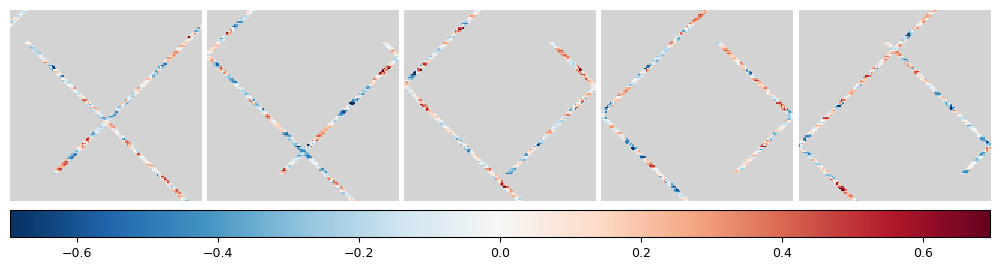

  Saved: figures/DirectUNet_GP/DirectUNet_GP_gt.png


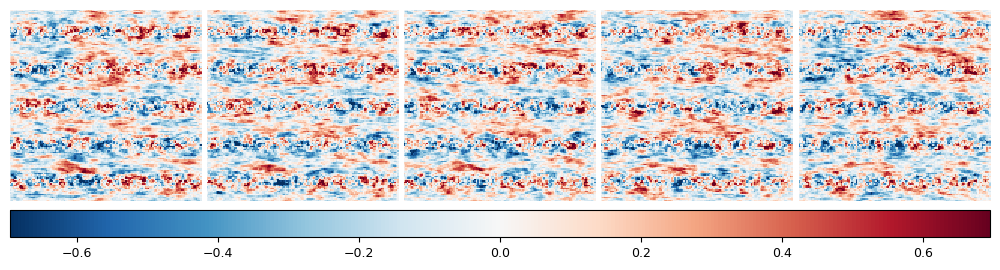

  Saved: figures/DirectUNet_GP/DirectUNet_GP_oi.png


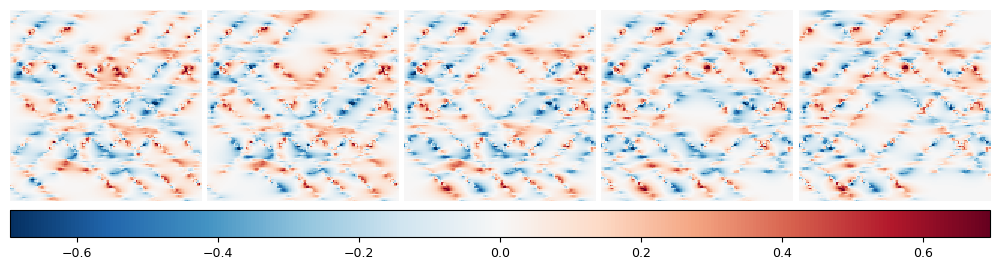

  Saved: figures/DirectUNet_GP/DirectUNet_GP_pred.png


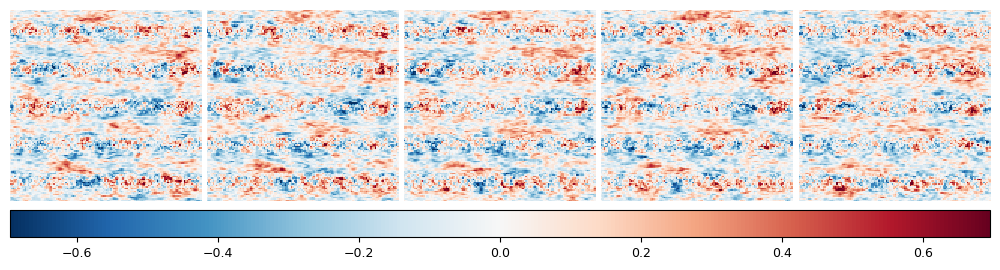

In [14]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'DirectUNet_GP'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C = datamodule.window_size
ws = C

obs_phys  = batch.input[_b].float().cpu().numpy() * s_norm + m_norm   # (C,H,W)
gt_phys   = batch.tgt[_b].float().cpu().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + ws].astype(np.float32)
pred_phys = x_hat[_b].float().cpu().numpy()       * s_norm + m_norm   # (C,H,W)

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

figures = [
    (obs_phys,  f'{FIG_TAG}_obs',  vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',   vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',   vmin_f, vmax_f, cmap_f),
    (pred_phys, f'{FIG_TAG}_pred', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)


## 📊 Metrics — DirectUNet vs OI

Evaluation at the **centre of the assimilation window** (`t=T_EVAL`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of prediction |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |


Evaluated 225 (test sample, timestep) pairs across the full test set

## Metrics -- full test set (whole domain), n=225 (sample,t) pairs



,Score ↑,RMSE ↓,σ_GT,σ_pred,λx [px]
Method,,,,,
DirectUNet (full test set),0.039 ± 0.033,0.2396 ± 0.0102,0.2492 ± 0.0058,0.1932 ± 0.0039,47.4 ± 43.0
OI baseline (full test set),0.096 ± 0.016,0.2253 ± 0.0040,0.2492 ± 0.0058,0.1578 ± 0.0062,43.1 ± 35.9


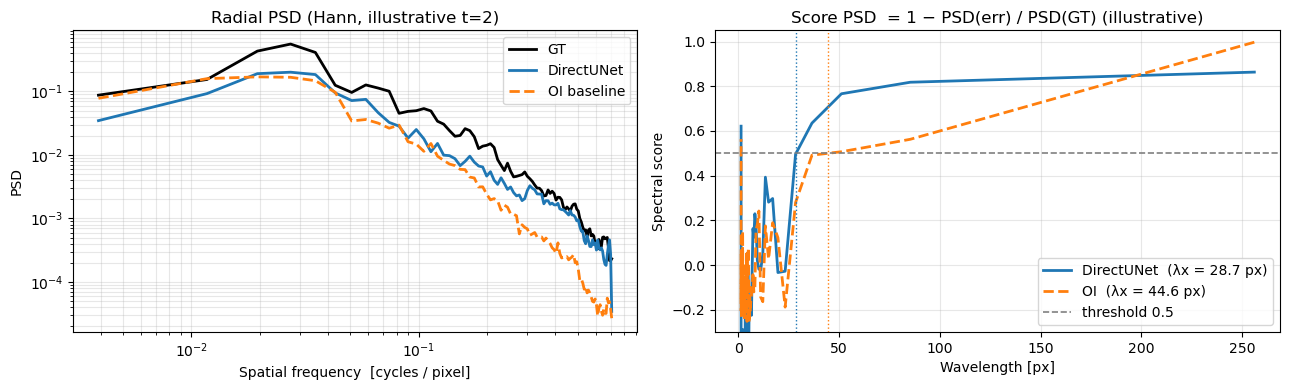

In [15]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import pandas as pd

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), comparing against the
# matching OI baseline slice for every (sample, timestep) pair. Deterministic
# method -- one forward pass per batch, no ensemble/CRPS.
_all_du = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_all_oi = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

for _tb in datamodule.test_dataloader():
    _y_b      = _tb.input.to(device=device, dtype=dtype)
    _x_true_b = _tb.tgt.to(device=device, dtype=dtype)
    _Bb, _Cb, _Hb, _Wb = _x_true_b.shape

    _mask_b     = _y_b.isfinite().to(dtype)
    _y_filled_b = _y_b.nan_to_num(0.0)
    with torch.no_grad():
        _x_hat_b = model(_y_filled_b, _mask_b)

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1
        _oi_traj = datamodule.oi[_start_t : _start_t + _Cb].astype(np.float32)   # (C, H, W)

        for _t in range(_Cb):
            _gt_p   = _x_true_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _pred_p = _x_hat_b[_bi, _t].float().cpu().numpy()  * s_norm + m_norm
            _oi_p   = _oi_traj[_t]

            _sigma = float(np.nanstd(_gt_p))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.nanmean((_pred_p - _gt_p) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.nanstd(_pred_p))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_pred_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _all_du['score'].append(_score)
            _all_du['rmse'].append(_rmse)
            _all_du['sigma_gt'].append(_sigma)
            _all_du['sigma_pred'].append(_sigma_pred)
            _all_du['lambda_x'].append(_lam)

            _rmse_oi  = float(np.sqrt(np.nanmean((_oi_p - _gt_p) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.nanstd(_oi_p))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    return {
        'Method'   : label,
        'Score ↑'  : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE ↓'   : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'σ_GT'     : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'σ_pred'   : f'{spr_m:.4f} ± {spr_s:.4f}',
        'λx [px]'  : f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }

row_du = _row(_all_du, 'DirectUNet (full test set)')
row_oi = _row(_all_oi, 'OI baseline (full test set)')

df_metrics = pd.DataFrame([row_du, row_oi]).set_index('Method')
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
gt_p_ex   = x_true[_b, T_EVAL].float().cpu().numpy() * s_norm + m_norm
pred_p_ex = x_hat[_b, T_EVAL].float().cpu().numpy()  * s_norm + m_norm
oi_p_ex   = datamodule.oi[start_t + T_EVAL].astype(np.float32)

wl_gt,  psd_gt_sig  = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_du2, psd_du_sig  = radial_psd_2d(pred_p_ex, dx=DX_PX)
wl_oi2, psd_oi_sig  = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_du, _, _, spec_du = psd_spectral_score(pred_p_ex, gt_p_ex, dx=DX_PX)
wl_oi, _, _, spec_oi = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_du = resolved_scale(wl_du, spec_du)
lambda_x_oi = resolved_scale(wl_oi, spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,  psd_gt_sig,  'black', '-',  'GT'),
    (wl_du2, psd_du_sig,  'C0',   '-',  'DirectUNet'),
    (wl_oi2, psd_oi_sig,  'C1',   '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_du = f'DirectUNet  (λx = {lambda_x_du:.1f} px)' if not np.isnan(lambda_x_du) else 'DirectUNet'
lbl_oi = f'OI  (λx = {lambda_x_oi:.1f} px)'          if not np.isnan(lambda_x_oi) else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_du, spec_du, 'C0', '-',  lbl_du),
    (wl_oi, spec_oi, 'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_du):
    ax.axvline(lambda_x_du, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi, color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/UNet_metrics_train.csv
